# 01 · Конфигурация: что можно настроить и на что это влияет

Настройки запуска хранятся в YAML и сливаются слоями (более поздний побеждает):

1. `configs/_base.yaml` -- общий протокол: один широкий пул токенов и одни настройки
   эволюции для всех наборов (пользователь не должен подбирать пул под задачу);
2. `configs/<набор>.yaml` -- только то, что нужно этой задаче сверх протокола;
3. `configs/variants.yaml[<вариант>]` -- сравниваемый вариант метода;
4. `--set key.path=value` из командной строки.

Секция `search` -- это собственный конфиг EPDE (`EpdeSearch(config=...)`).

In [1]:
import os, sys, time
from pathlib import Path
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')   # before numpy: EPDE is faster single-threaded
os.environ.setdefault('OMP_NUM_THREADS', '1')

# find projects/pic (this notebook lives in projects/pic/notebooks)
PIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'epde_bench').is_dir())
sys.path[:0] = [str(PIC.parent.parent), str(PIC)]
import epde

import numpy as np
import matplotlib.pyplot as plt
from epde_bench import datasets, metrics, load_config, resolve_for_problem, discover
from epde_bench.plotting import plot_problem, plot_front
from epde_bench.truthcheck import check, print_check
%matplotlib inline
print('EPDE imported; PIC notebook environment ready')

EPDE imported; PIC notebook environment ready


In [2]:
print((PIC / 'configs' / '_base.yaml').read_text())

# Common protocol for every data set.
#
# The idea (from the group's former benchmark, projects/thesis on main): one
# broad token pool and one set of evolutionary settings for all problems, so
# the user does not tune the pool per problem. Data-set files only add what a
# problem cannot do without (a special token, a longer boundary, a bigger
# population for coupled systems).
#
# `search` is passed to EpdeSearch(config=...) unchanged; see
# epde/interface/search_config.py for every key and its default.

loader: {}                       # keyword arguments of the data-set loader

search:
  domain:
    boundary_width: auto         # 10 % of each axis is dropped at the edges
  preprocessing:
    default_preprocessor_type: FD
    preprocessor_kwargs: {}
    max_deriv_order: auto        # 2 in time, 4 in every space axis
  search_space:
    data_fun_pow: 3              # u, u^2, u^3
    deriv_fun_pow: 2             # u_x, (u_x)^2
    equation_terms_max_number: 10
    equation_factors_max_

In [3]:
print((PIC / 'configs' / 'lorenz.yaml').read_text())
cfg = load_config('lorenz')
problem = datasets.load('lorenz')
import yaml; print(yaml.safe_dump(resolve_for_problem(cfg, problem), sort_keys=False))

# Three coupled first-order equations (window chosen by the loader, see
# datasets.py). Boundary as in projects/pinn/gate.py.
search:
  domain: {boundary_width: 10}
  preprocessing: {max_deriv_order: [1]}
  evolution: {population_size: 48}

domain:
  boundary_width: 10
preprocessing:
  default_preprocessor_type: FD
  preprocessor_kwargs: {}
  max_deriv_order:
  - 1
search_space:
  data_fun_pow: 3
  deriv_fun_pow: 2
  equation_terms_max_number: 10
  equation_factors_max_number:
    factors_num:
    - 1
    - 2
    probas:
    - 0.65
    - 0.35
  tokens:
  - family: grid
    labels:
    - x
    max_power: 2
    dimensionality: 0
  - family: fixed_trigonometric
    freq: 2.0
    dimensionality: 0
objectives: {}
solver:
  use_solver: false
  device: cpu
evolution:
  population_size: 48
  training_epochs: 5
runtime:
  verbose_params:
    show_iter_idx: false
  memory_for_cache: 2



## Все настройки EPDE и их значения по умолчанию

`load_search_config(None)` возвращает поставляемые умолчания по группам.

In [4]:
from dataclasses import asdict
from epde.interface.search_config import load_search_config, METRIC_MENUS, SPARSITY_REGISTRY, TOKEN_REGISTRY
defaults = load_search_config(None)
for group in ['domain', 'preprocessing', 'search_space', 'objectives', 'evolution', 'runtime']:
    values = asdict(getattr(defaults, group))
    values.pop('operators', None)
    print(f'{group}:', values)
print('\nobjective menus:', METRIC_MENUS)
print('sparsity operators:', SPARSITY_REGISTRY)
print('declarative token families:', list(TOKEN_REGISTRY))

domain: {'boundary_width': 5, 'time_axis': 0}
preprocessing: {'default_preprocessor_type': 'poly', 'preprocessor_kwargs': {}, 'max_deriv_order': 1}
search_space: {'data_fun_pow': 1, 'deriv_fun_pow': 1, 'equation_terms_max_number': 6, 'equation_factors_max_number': 1, 'rps_amplification_cap': 100.0, 'tokens': ()}
objectives: {'multiobjective_mode': True, 'discrepancy_metric': 'wape', 'second_objective': 'instability', 'complexity_metric': 'factors', 'instability_metric': 'chi2', 'single_objective_metric': 'discrepancy', 'anchor_on_residual': False, 'sparsity_cls': <class 'epde.operators.common.sparsity.VWSRSparsity'>, 'sparsity_kwargs': {}}
evolution: {'population_size': 6, 'training_epochs': 100, 'neighbors_number': 3, 'PBI_penalty': 5.0, 'subregion_mating_limitation': 0.9, 'solution_params': {}, 'director_params': {'variation_params': {}, 'mutation_params': {}, 'sorter_params': {}, 'pareto_combiner_params': {}, 'pareto_updater_params': {}}}
runtime: {'memory_for_cache': 15, 'verbose_p

## Варианты методов, которые сравнивает бенчмарк

In [5]:
print((PIC / 'configs' / 'variants.yaml').read_text())

# Method variants compared by the benchmark. Each entry is merged on top of
# _base.yaml + <dataset>.yaml. `default` changes nothing: it is EPDE as
# shipped on domain_refactor (wape discrepancy, chi2 instability as the second
# Pareto axis, VWSR sparsity) with the FD preprocessor of the base protocol.

default: {}

# Old EPDE: L2 discrepancy, LASSO sparsity, complexity as the second axis
# (the `legacy` pipeline of the group's former benchmark).
legacy:
  search:
    objectives:
      discrepancy_metric: l2
      sparsity_cls: lasso
      sparsity_kwargs: {initial_sparsity_interval: [1.0e-12, 1.0e-4]}
      second_objective: complexity

# Derivatives from local polynomial fits instead of finite differences.
poly:
  search:
    preprocessing:
      default_preprocessor_type: poly

# Support chosen by the knee of the residual-vs-size curve instead of VWSR.
knee:
  search:
    objectives:
      sparsity_cls: knee

# Instability measured by cross-validation over windows instead of chi2.
i

## Производные: конечные разности против полиномиального сглаживания

Препроцессор важнее всего при шуме. Ниже вторая производная сигнала Ван дер Поля с
шумом 2 %: штатными препроцессорами EPDE `FD` и `poly`. Это тот же механизм,
который используется при поиске; `poly` дифференцирует локальный полином Чебышёва.

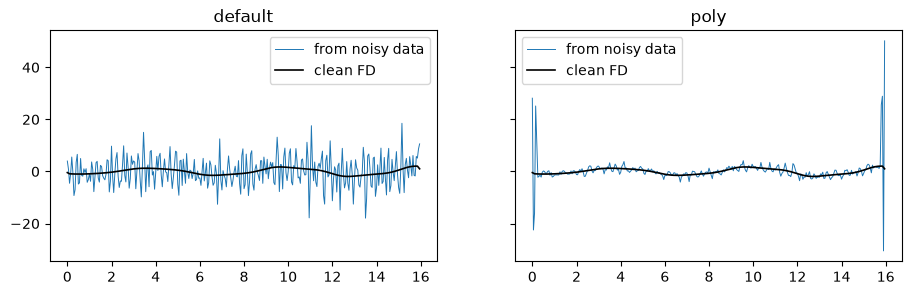

In [6]:
from epde_bench.preprocessing import prepare_data
p = datasets.load('vdp'); t = p.grids[0]
clean = p.data; noisy = p.noisy(2, seed=0)
fd_cfg = resolve_for_problem(load_config('vdp'), p)
_, clean_derivs = prepare_data(p, clean, fd_cfg)
d2_true = clean_derivs['u'][:, 1]
fig, ax = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
for a, variant in zip(ax, ['default', 'poly']):
    cfg = resolve_for_problem(load_config('vdp', variant), p)
    # Keep the demonstration deterministic and avoid multiprocessing in a kernel.
    if variant == 'poly':
        cfg['preprocessing'].setdefault('preprocessor_kwargs', {})['mp_poolsize'] = 1
    _, derivatives = prepare_data(p, noisy, cfg)
    a.plot(t, derivatives['u'][:, 1], lw=.7, label='from noisy data')
    a.plot(t, d2_true, 'k', lw=1.2, label='clean FD'); a.set_title(variant); a.legend()
plt.show()

## Токены, которым нужны данные: вынуждающая сила, связи, свои функции

Декларативные семейства задаются в `search_space.tokens`. Семейства, которым нужен
массив (входной сигнал, поле коэффициента), -- это `CacheStoredTokens`; загрузчики
объявляют их в `Problem.token_groups`, например момент, который приводит в движение
руку робота:

forcing ['u_in'] may stand alone


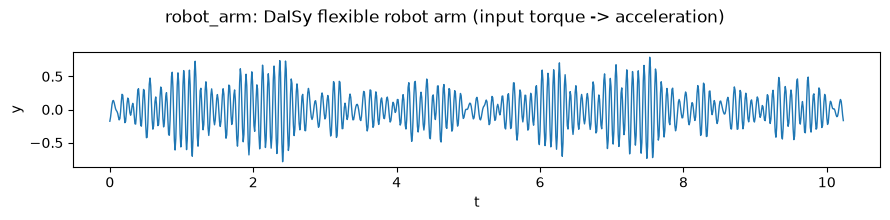

In [7]:
p = datasets.load('robot_arm')
for token_type, tensors, meaningful in p.token_groups:
    print(token_type, list(tensors), 'may stand alone' if meaningful else 'factor only')
plot_problem(p); plt.show()

## Ловушка с тригонометрическими токенами

Те же данные и настройки, отличается только тригонометрическое семейство.
`trig_native` -- это `TrigonometricTokens(freq=(2 - 1e-8, 2 + 1e-8))`, как в исходных
скриптах.

In [8]:
from epde_bench.nbcache import cached_run
rec = cached_run('ode', variant='trig_native', noise=0.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok

 fit 37 s (from cache)
[0] <- compromise pick
     -0.03094289692505856 * u{power: 2.0} * sin{power: 1.0, freq: 1.999999991099584, dim: 0.0} + 0.030942894861381038 * u{power: 2.0} * sin{power: 1.0, freq: 2.0000000008555445, dim: 0.0} + 0.9999999552836661 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 1.999999993810918, dim: 0.0} + 0.0 = du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0000000029822393, dim: 0.0}
{'front_size': 1, 'selected_index': 0, 'success_front': False, 'success_selected': False, 'hamming_min': 4, 'hamming_selected': 4, 'coef_error': None}


In [9]:
from epde_bench.nbcache import cached_run
rec = cached_run('ode', variant='default', noise=0.0, seed=0)
print(rec['status'], f"fit {rec.get('fit_seconds', 0):.0f} s", '(from cache)' if rec.get('from_cache') else '')
for i, system in enumerate(rec.get('front', [])):
    print(f'[{i}]' + (' <- compromise pick' if i == rec['metrics']['selected_index'] else ''))
    for eq in system:
        print('    ', eq)
print({k: v for k, v in rec.get('metrics', {}).items() if k != 'best_index'})
if rec['status'] != 'ok':
    print('Search needs attention:', rec.get('error', rec['status']))

ok fit 40 s (from cache)
[0] <- compromise pick
     -3.984485683554886 * u{power: 1.0} + 1.496973458999215 * x{power: 1.0, dim: 0.0} + -0.9885206385764294 * du/dx0{power: 1.0} * sin{power: 1.0, freq: 2.0, dim: 0.0} + 0.0 = d^2u/dx0^2{power: 1.0}
{'front_size': 1, 'selected_index': 0, 'success_front': True, 'success_selected': True, 'hamming_min': 0, 'hamming_selected': 0, 'coef_error': 0.005791878178457512}


Со штатным семейством библиотеки фронт -- тождество из токенов `sin`, частоты
которых различаются в 9-м знаке: нулевая ошибка, нулевая нестабильность, и неверно.

## Популяция и эпохи

Стоимость запуска растёт как `population_size x training_epochs`. Быстрый взгляд
на Ван дер Поле:

In [10]:
from epde_bench.nbcache import cached_run
for epochs in [2, 5, 10]:
    rec = cached_run('vdp', overrides={'search': {'evolution': {'training_epochs': epochs}}})
    if rec['status'] != 'ok':
        print('search did not complete:', rec['status'], rec.get('error', ''))
        continue
    m = rec['metrics']
    print(f"epochs {epochs:2d}: {rec['fit_seconds']:5.1f} s, front {m['front_size']}, "
          f"truth on front {m['success_front']}, min Hamming {m['hamming_min']}")

epochs  2:  31.3 s, front 1, truth on front True, min Hamming 0


epochs  5:  72.9 s, front 1, truth on front True, min Hamming 0


epochs 10: 161.3 s, front 1, truth on front True, min Hamming 0
